# 🟢 TASK 1 — ১০ ধাপে পুরো Project

Step 0: Problem বোঝা
Target Column: diagnosis

M = Malignant (ক্যান্সার আছে) ☠️
B = Benign (ক্যান্সার নেই) ✅

👉 এটাও একটা Binary Classification Problem

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyarrow import scalar

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("Cancer_Data.csv")

df.head(5)



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [4]:
df.columns.tolist()


['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

In [5]:
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

## Step 4: Unnecessary Column বাদ দেওয়া

In [6]:
df = df.drop(['id','Unnamed: 32'], axis=1)
print(df.shape)

(569, 31)


## Step 5: Target Variable বোঝা

diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\evan\AppData\Local\Temp\ipykernel_10704\1447085174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


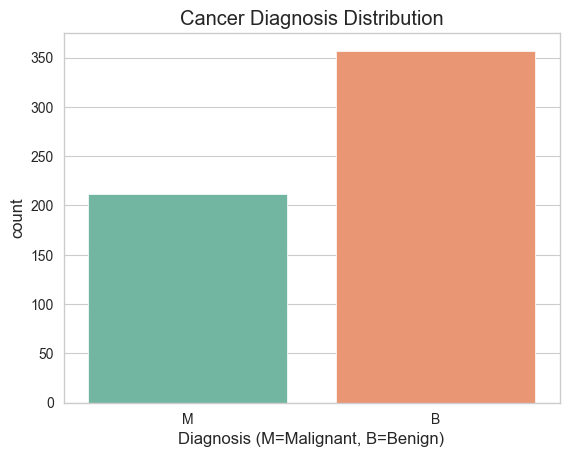

In [7]:
print(df['diagnosis'].value_counts())

sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title("Cancer Diagnosis Distribution")
plt.xlabel("Diagnosis (M=Malignant, B=Benign)")
plt.show()

## Step 6: Data Visualization

C:\Users\evan\AppData\Local\Temp\ipykernel_10704\4261650373.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='diagnosis', y='radius_mean',data=df, palette='Set2')


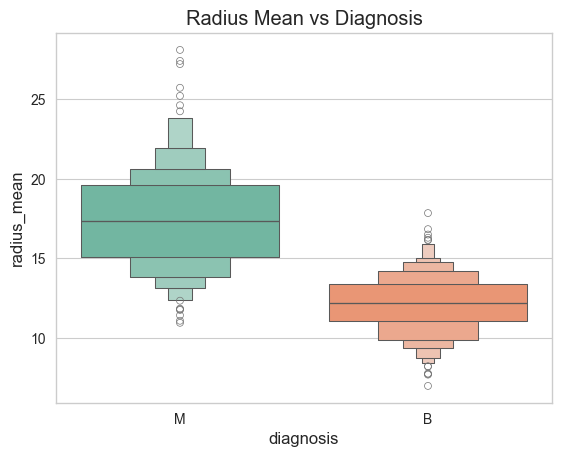

In [8]:
# radius_mean দিয়ে দুই class তুলনা
sns.boxenplot(x='diagnosis', y='radius_mean',data=df, palette='Set2')
plt.title("Radius Mean vs Diagnosis")
plt.show()

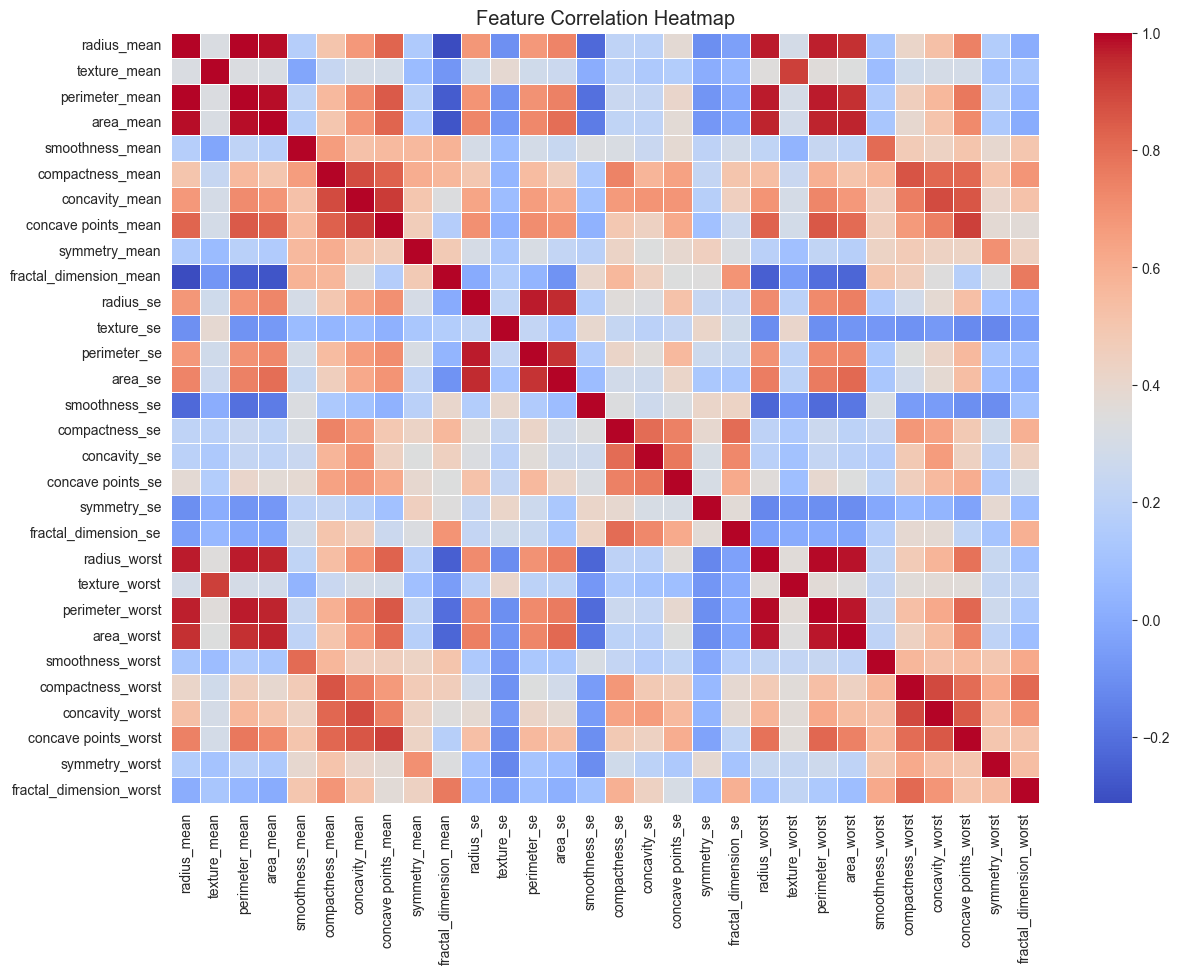

In [9]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

df_numeric = df.select_dtypes(include='number')

sns.heatmap(df_numeric.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 7: Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()
df_encoded['diagnosis']= le.fit_transform(df_encoded['diagnosis'])

print("before", df['diagnosis'].unique())
print("after", df_encoded['diagnosis'].unique())

before ['M' 'B']
after [1 0]


## Step 8: Feature & Target আলাদা করা

In [11]:
X = df_encoded.drop('diagnosis', axis =1)
Y = df_encoded['diagnosis']
print(X.shape)
print(Y.shape)

(569, 30)
(569,)


## Step 9: Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y , test_size= 0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Step 10: Model Train, Predict & Accuracy

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

accuracy = model.score(X_test, Y_test)
print(round(accuracy * 100, 2) ,"%")

94.74 %


# 🟢 TASK 2 — ৩টা TODO

In [14]:
# Step 1: Missing values খোঁজা
print("=== Missing Value Check ===")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

=== Missing Value Check ===
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total missing: 0


In [15]:
# Step 2: '?' দিয়ে hidden missing আছে কিনা
for col in df.columns:
    if df[col].dtype == 'object':
        if '?' in df[col].values:
            print(f"{col} এ '?' আছে!")
        else:
            print(f"{col}: কোনো hidden missing নেই ✅")

diagnosis: কোনো hidden missing নেই ✅


## TODO 2: Categorical Encoding

In [16]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['diagnosis']


In [17]:
# Step 3: সিদ্ধান্ত ও Imputation
print("""
সিদ্ধান্ত:
- Unnamed: 32 column সম্পূর্ণ খালি → drop করে দিয়েছি
- বাকি কোনো column এ missing নেই
- তাই আলাদা imputation দরকার নেই ✅
""")


Encoding সিদ্ধান্ত:
- diagnosis column: শুধু 2টা value (M/B) → Label Encoding সেরা
- বাকি সব column: already numeric → encoding লাগবে না



In [21]:
print("Categorical Column")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

Categorical Column
['diagnosis']


In [22]:
# Step 2: সিদ্ধান্ত
print("""
Encoding সিদ্ধান্ত:
- diagnosis column: শুধু 2টা value (M/B) → Label Encoding সেরা
- বাকি সব column: already numeric → encoding লাগবে না
""")


Encoding সিদ্ধান্ত:
- diagnosis column: শুধু 2টা value (M/B) → Label Encoding সেরা
- বাকি সব column: already numeric → encoding লাগবে না



In [25]:
# Step 3: Label Encoding apply করা
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()
df_encoded['diagnosis'] = le.fit_transform(df_encoded['diagnosis'])

print("Before → After:")
print(f"M → {le.transform(['M'])[0]}")
print(f"B → {le.transform(['B'])[0]}")
print("\nFinal encoded data (প্রথম ৩ row):")
print(df_encoded[['diagnosis', 'radius_mean', 'area_mean']].head(3))

Before → After:
M → 1
B → 0

Final encoded data (প্রথম ৩ row):
   diagnosis  radius_mean  area_mean
0          1        17.99     1001.0
1          1        20.57     1326.0
2          1        19.69     1203.0


## TODO 3: Feature Scaling

| Code | কী করছে |
|------|---------|
| `.describe()` | statistics দেখায় |
| `.loc[['min', 'max']]` | শুধু min ও max row |
| `.T` | Transpose — row কে column এ বদলায়, পড়তে সহজ |

**Output দেখাবে বিশাল পার্থক্য:**
```
area_mean:      143 → 2501   (বড় range)
smoothness_mean: 0.05 → 0.16  (ছোট range)

In [31]:
# Step 1: Value range চেক করা
print("প্রতিটা column এর range:")
print(df_encoded.describe().loc[['min', 'max']].T)



প্রতিটা column এর range:
                                min         max
diagnosis                  0.000000     1.00000
radius_mean                6.981000    28.11000
texture_mean               9.710000    39.28000
perimeter_mean            43.790000   188.50000
area_mean                143.500000  2501.00000
smoothness_mean            0.052630     0.16340
compactness_mean           0.019380     0.34540
concavity_mean             0.000000     0.42680
concave points_mean        0.000000     0.20120
symmetry_mean              0.106000     0.30400
fractal_dimension_mean     0.049960     0.09744
radius_se                  0.111500     2.87300
texture_se                 0.360200     4.88500
perimeter_se               0.757000    21.98000
area_se                    6.802000   542.20000
smoothness_se              0.001713     0.03113
compactness_se             0.002252     0.13540
concavity_se               0.000000     0.39600
concave points_se          0.000000     0.05279
symmetry_se    

In [32]:
# Step 2: সিদ্ধান্ত
print("""
Scaling সিদ্ধান্ত:
- area_mean এর range: ~143 থেকে ~2501
- smoothness_mean এর range: ~0.05 থেকে ~0.16
- এত বড় পার্থক্য থাকলে অনেক algorithm ভুল শেখে
- Decision Tree এর জন্য scaling না লাগলেও
  ভবিষ্যতে KNN/SVM এর জন্য এখনই করা ভালো ✅
""")


Scaling সিদ্ধান্ত:
- area_mean এর range: ~143 থেকে ~2501
- smoothness_mean এর range: ~0.05 থেকে ~0.16
- এত বড় পার্থক্য থাকলে অনেক algorithm ভুল শেখে
- Decision Tree এর জন্য scaling না লাগলেও
  ভবিষ্যতে KNN/SVM এর জন্য এখনই করা ভালো ✅



In [34]:
# Step 3: StandardScaler apply করা
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('diagnosis', axis=1)
y = df_encoded['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (area_mean):")
print(X['area_mean'].head())

print("\nAfter scaling (area_mean):")
print(X_scaled['area_mean'].head())

Before scaling (area_mean):
0    1001.0
1    1326.0
2    1203.0
3     386.1
4    1297.0
Name: area_mean, dtype: float64

After scaling (area_mean):
0    0.984375
1    1.908708
2    1.558884
3   -0.764464
4    1.826229
Name: area_mean, dtype: float64
